# EX04 — Graphify + Obsidian Reverse-Engineering Agent · Project Run

**University of Haifa — Agentic AI (Dr. Yoram Segal, L07)**
Authors: Eyal Shtinmtez (314884834) · Imree Cohen (312359284)

This notebook walks the **whole project, one block per phase (Phase 0 → Phase 8)**, and
shows the **real output of each phase** by calling the SDK façade
(`ex04_graphify_agent.sdk.Ex04Sdk`) — the single seam all business logic lives behind.

**What the project does.** It reverse-engineers `martinpeck/broken-python`'s
`polygons/polygons.py` using a **Graphify knowledge graph** + an **Obsidian vault**, then
fixes the bug with a **graph-guided LangGraph agent** that reads `index.md` / `hot.md` /
`graph.json` instead of dumping raw source into the LLM context — and proves, via the
gatekeeper's token ledger, that graph-guided navigation uses **fewer tokens** than a naive
"dump every file" baseline **without** losing bug-localization accuracy.

> **Keyless by design (ADR-0005).** Every cell below runs with **no provider API key** —
> the gatekeeper injects a mock client. The *keyed* live-run numbers (real Gemini calls)
> are frozen in `reports/` and shown alongside the reproducible keyless numbers.

## Setup — locate the repo root and import the SDK

In [1]:
import json
import os
import re
import sys
import tempfile
from collections import Counter
from pathlib import Path

from ex04_graphify_agent import __version__
from ex04_graphify_agent.graph_reader import GraphReader
from ex04_graphify_agent.sdk import Ex04Sdk

# Walk up from the notebook's dir until we find the project constitution (CLAUDE.md).
here = Path.cwd()
root = next(p for p in (here, *here.parents) if (p / "CLAUDE.md").exists())
os.chdir(root)
sys.path.insert(0, "scripts")  # the README chart builders live here
print("repo root:", root)

sdk = Ex04Sdk()
print("ex04_graphify_agent version:", __version__)

repo root: /home/user/ex04-graphify-agent
ex04_graphify_agent version: 0.1.0


## Phase 0 — Planning

Before any code: a binding planning layer. `docs/ASSIGNMENT.md` is the requirement-ID
(`R#.#`) source of truth; `docs/PRD*.md`, `docs/PLAN.md` and the ADRs (`docs/adr/`) lock the
architecture. **Output:** the planning documents that govern every later phase.

In [2]:
planning = sorted(p.name for p in Path("docs").glob("*.md"))
adrs = sorted(p.name for p in Path("docs/adr").glob("*.md"))
req_ids = len(set(re.findall(r"\bR\d+\.\d+", Path("docs/ASSIGNMENT.md").read_text())))

print("Planning docs:", *planning, sep="\n  - ")
print("\nADRs:", *adrs, sep="\n  - ")
print(f"\nDistinct requirement IDs tracked in ASSIGNMENT.md: {req_ids}")

Planning docs:
  - ASSIGNMENT.md
  - KNOWN_LIMITATIONS.md
  - PLAN.md
  - PRD.md
  - PRD_agent_workflow.md
  - PRD_graph_reader.md
  - PRD_token_comparison.md
  - PRD_weakness_detector.md
  - PROMPTS.md
  - TODO.md
  - VERIFICATION.md

ADRs:
  - 0001-langgraph-over-crewai.md
  - 0002-gatekeeper-present-or-omitted.md
  - 0003-target-repo-and-bug.md
  - 0004-graph-guided-retrieval-over-naive-dump.md
  - 0005-keyless-by-default-test-strategy.md
  - 0006-multi-agent-orchestration.md

Distinct requirement IDs tracked in ASSIGNMENT.md: 51


## Phase 1 — Scaffold

`uv`-managed package, SDK-first layout, config-driven everything (no hardcoded values),
strict tooling gates (`ruff` / `mypy --strict` / `pytest ≥90%`). **Output:** the installed
package, its modules, and the JSON config that drives the agent.

In [3]:
modules = sorted(
    str(p.relative_to("src/ex04_graphify_agent"))
    for p in Path("src/ex04_graphify_agent").rglob("*.py")
    if p.name != "__init__.py"
)
print("SDK-first package — src/ex04_graphify_agent/")
for m in modules:
    print("  ", m)

print("\nConfig files (config/):")
for c in sorted(Path("config").glob("*.json")):
    print("  ", c.name)

print("\nagent.json (provider/model are config-driven, never hardcoded):")
agent_cfg = json.loads(Path("config/agent.json").read_text())
print(json.dumps({k: agent_cfg[k] for k in ("provider", "model") if k in agent_cfg}, indent=2))

SDK-first package — src/ex04_graphify_agent/
   agent_workflow/agents.py
   agent_workflow/config.py
   agent_workflow/context.py
   agent_workflow/deps.py
   agent_workflow/fix_target.py
   agent_workflow/graph_def.py
   agent_workflow/nodes.py
   agent_workflow/nodes_graph.py
   agent_workflow/nodes_naive.py
   agent_workflow/nodes_shared.py
   agent_workflow/prompts.py
   agent_workflow/state.py
   cli.py
   gatekeeper/client.py
   gatekeeper/config.py
   gatekeeper/provider.py
   gatekeeper/token_log.py
   graph_reader/filters.py
   graph_reader/loader.py
   graph_reader/metrics.py
   graph_reader/models.py
   graph_reader/reader.py
   obsidian_writer/config.py
   obsidian_writer/hot.py
   obsidian_writer/index.py
   obsidian_writer/notes.py
   obsidian_writer/ranking.py
   sdk.py
   self_grade/checks.py
   self_grade/config.py
   self_grade/grader.py
   self_grade/models.py
   token_comparison/comparison.py
   token_comparison/correctness.py
   token_comparison/cost.py
   token_co

## Phase 2 — `graph_reader` (the typed graph access layer)

`GraphReader` is the **only** module that parses `graph.json`. It precomputes degree +
betweenness centrality and exposes a typed query surface. **Output:** the shape of the
PRE-FIX graph and the most central nodes — the agent's map of the codebase.

In [4]:
gr = GraphReader()
nodes, edges = gr.all_nodes(), gr.all_edges()
print(f"graph.json — {len(nodes)} nodes, {len(edges)} edges, {len(gr.communities())} communities\n")

print("Top 5 nodes by degree centrality:")
for nv in gr.top_n_by_degree(5):
    print(f"  degree={nv.degree}  bw={nv.betweenness:.3f}  {nv.id}")

print("\nEdge confidence breakdown (EXTRACTED / INFERRED / AMBIGUOUS):")
conf = Counter(e.confidence.value for e in edges)
for k, v in conf.items():
    print(f"  {k}: {v}")

graph.json — 23 nodes, 20 edges, 6 communities

Top 5 nodes by degree centrality:
  degree=4  bw=0.056  polygons_polygons_polygon
  degree=3  bw=0.017  mathsquiz_readme_maths_quiz
  degree=2  bw=0.013  readme_broken_python
  degree=2  bw=0.000  mathsquiz_mathsquiz
  degree=2  bw=0.000  mathsquiz_mathsquiz_final_py

Edge confidence breakdown (EXTRACTED / INFERRED / AMBIGUOUS):
  EXTRACTED: 18
  INFERRED: 2


## Phase 3 — `weakness_detector` (the six PART-C signals)

Six graph signals → bug-class hypotheses, each carrying an
**Observe → Relation → Confidence → Context → Source-validation** trail and an evidence tag
(**EXTRACTED / INFERRED / AMBIGUOUS**). **Output:** the ranked findings that point the agent
at the bug.

In [5]:
findings = sdk.detect_weaknesses()
print(f"{len(findings)} ranked findings\n")
for f in findings:
    print(f"[signal {f.signal}] {f.tag:9} {f.priority:9} -> {f.hypothesis[:90]}...")

7 ranked findings

[signal 1] EXTRACTED primary   -> `Polygon` (`polygons_polygons_polygon`) is the highest-degree node (degree 4) and bridges ...
[signal 6] AMBIGUOUS primary   -> `calc_polygon_details()`'s returned dict may duplicate the unused `Polygon` class's fields...
[signal 5] EXTRACTED primary   -> Three weakly-connected rationale TODO nodes in Community 1 are the developer's own notes d...
[signal 2] INFERRED  secondary -> The graph suggests `Broken Python Project` may be conceptually related to `Maths Quiz Docu...
[signal 2] INFERRED  secondary -> The graph suggests `mathsquiz.py` may be semantically similar to `mathsquiz-final.py` (con...
[signal 3] EXTRACTED secondary -> `mathsquiz-final.py` is referenced by `Maths Quiz Documentation` but the file is absent on...
[signal 4] INFERRED  secondary -> `polygons.py` may lack a `sides >= 3` guard before `calc_polygon_details` / `draw_polygon`...


## Phase 4 — Obsidian vault build (`hot.md`)

`hot.md` is the *"where to look first"* note — **generated**, not hand-curated: ranked by
`centrality x proximity-to-bug-node`. (Written to a temp vault here so the committed,
graded deliverable stays untouched — CLAUDE.md §4 baseline immutability.) **Output:** the
generated ranking the graph-guided agent reads first.

In [6]:
tmp_vault = Path(tempfile.mkdtemp())
hot_path = sdk.generate_hot(vault_dir=tmp_vault)
print(hot_path.read_text())

print("Committed PRE-FIX vault (obsidian/) — per-node notes + index:")
print("  ", len(list(Path("obsidian").glob("*.md"))), "markdown notes")

# Hot — Where to look first

Ranked by centrality * proximity to the bug node `polygons_polygons_polygon` (R5.6.1, PLAN §5): centrality = 0.6·degree + 0.4·betweenness (max-normalized); proximity = 1 / (1 + shortest-path distance to the bug node). File-container roots are excluded.

1. [[polygons_polygons_polygon|Polygon]] — degree=4 · bw=0.0563 · community=4 · polygons/polygons.py:L3
2. [[polygons_polygons_calc_polygon_details|calc_polygon_details()]] — degree=2 · bw=0.0000 · community=4 · polygons/polygons.py:L13
3. [[object|Object]] — degree=1 · bw=0.0000 · community=4 · 
4. [[polygons_polygons_polygon_init|.__init__()]] — degree=1 · bw=0.0000 · community=4 · polygons/polygons.py:L5
5. [[polygons_polygons_draw_polygon|draw_polygon()]] — degree=1 · bw=0.0000 · community=1 · polygons/polygons.py:L41
6. [[polygons_polygons_rationale_18|# TODO: find a better way to work this stuff out]] — degree=1 · bw=0.0000 · community=1 · polygons/polygons.py:L18
7. [[polygons_polygons_rationale_33|# 

### Does the ranking actually surface the bug? (ROC)

Ground truth = *a node belongs to the buggy file* `polygons/polygons.py` (7 of 20 entity nodes). Every node is scored two ways and the ROC is plotted: the **composite** `hot.md` metric (centrality × proximity-to-bug) vs **raw centrality** alone. The composite ranking — the one that drives graph-guided retrieval — cleanly separates the buggy file (AUC ≈ 0.95) where raw centrality is near chance (AUC ≈ 0.53). That gap *is* the R1.4 design decision, made visible. *(Small-N and illustrative; the proximity term is anchored on the Signal-1 god node, itself graph-derived.)*

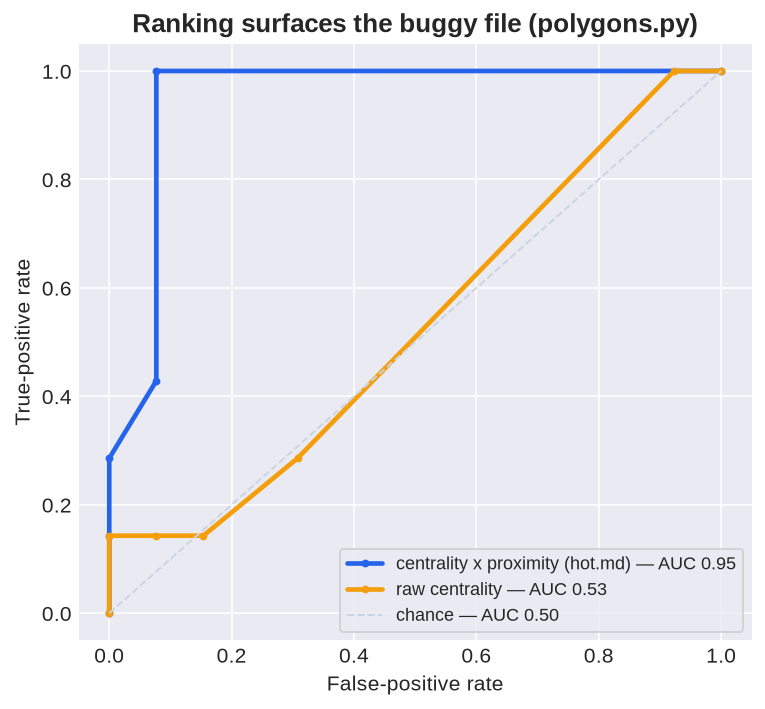

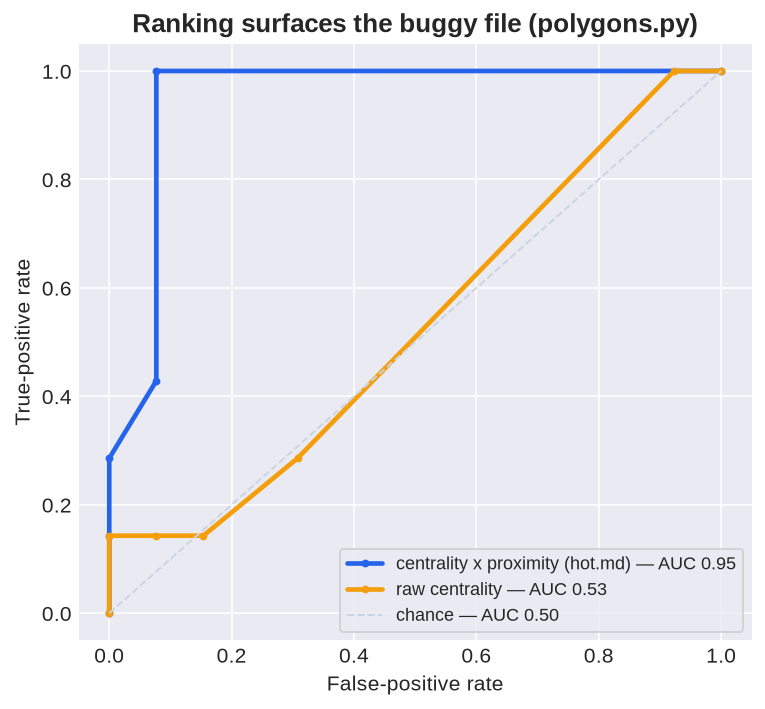

In [7]:
import make_charts

make_charts._style()  # modern chart theme, shared with the committed PNGs
make_charts.fig_roc()

## Phase 5 — LangGraph agent (`agent_workflow`)

The LangGraph state machine: **Plan → Retrieve(graph) → Hypothesize → Validate(source) →
Fix → Report**, in two routes — `graph_guided` (reads `hot.md` + the one bug file) vs
`naive` (dumps the whole repo). Below, both run **keyless** (mock gatekeeper). **Output:**
the agent trace — what entered context, the validated hypothesis, and the per-node token
ledger.

In [8]:
def trace(run_type: str) -> dict:
    st = sdk.run_agent(run_type)
    print(f"=== {run_type} ===")
    print("  files in context:", [Path(p).name for p in st["files_read"]])
    print("  validated:", st["validated"])
    print("  token ledger:", st["token_usage"])
    return st


g = trace("graph_guided")
print()
n = trace("naive")
print("\nValidated hypothesis (graph-guided):\n  ", g["current_hypothesis"].hypothesis)

=== graph_guided ===
  files in context: ['index.md', 'hot.md', 'polygons.py']
  validated: True
  token ledger: [{'node': 'plan', 'input_tokens': 30, 'output_tokens': 2}, {'node': 'fix', 'input_tokens': 473, 'output_tokens': 2}]



=== naive ===
  files in context: ['LICENSE.txt', 'README.md', 'README.md', 'mathsquiz-step1.py', 'mathsquiz-step2.py', 'mathsquiz-step3.py', 'mathsquiz.py', 'polygons.py']
  validated: False
  token ledger: [{'node': 'plan', 'input_tokens': 30, 'output_tokens': 2}, {'node': 'fix', 'input_tokens': 1800, 'output_tokens': 2}]

Validated hypothesis (graph-guided):
   `Polygon` (`polygons_polygons_polygon`) is the highest-degree node (degree 4) and bridges its communities — it is the core abstraction and the first place to investigate.


The keyless run uses a mock LLM, so the *diff* above is a placeholder. The **real keyed fix**
that the agent produced (and that passes the 3-part correctness gate) is frozen in
`reports/diff_polygons.md`:

In [9]:
diff = Path("reports/diff_polygons.md").read_text()
start = diff.index("```diff")
print(diff[start : start + 900])

```diff
--- a/data/broken-python/polygons/polygons.py
+++ b/data/broken-python/polygons/polygons.py
@@ -1,44 +1,31 @@
 import turtle
 
-class Polygon(Object):
+
+class Polygon(object):
 
     def __init__(self, sides, internal_angles_sum, internal_angle):
         self.sides = sides
         self.internal_angles_sum = internal_angles_sum
         self.internal_angle = internal_angle
-        
+
 
 # calculate the total internal angles, and the angles within
 # a regular version of the polygon
 def calc_polygon_details(sides):
 
-    internal_angles_sum = 0
-    internal_angles = 0
-
-    # TODO: find a better way to work this stuff out
-    if sides == 3:
-        internal_angles_sum = 180
-        internal_angles = 60
-    elif sides == 4:
-        internal_angles_sum = 360
-        internal_angles = 90
-    else:
-        internal_angles_sum = 1000
-        internal_angles = 200
+    i


## Phase 6 — Token comparison (the thesis: graph-guided < naive)

`token_comparison` runs both routes through the gatekeeper and reports the token delta from
its **authoritative ledger** (not estimates). Below is the reproducible **keyless** run;
underneath, the frozen **keyed** live-run numbers. **Output:** the input-token reduction
that is the project's core claim.

In [10]:
tmp = Path(tempfile.mkdtemp())
report = sdk.compare_tokens(report_path=tmp / "tc.md", runs_dir=tmp / "runs")
text = report.read_text()
# Show the comparison table + the R4.1 reduction headline.
print("\n".join(text.splitlines()[:6]))
print()
red = next(line for line in text.splitlines() if "fewer input tokens" in line)
print("Keyless (reproducible):", red)

keyed = Path("reports/token_comparison.md").read_text()
print(
    "Keyed (frozen live run):",
    next(line for line in keyed.splitlines() if "fewer input tokens" in line),
)

# Token Comparison - Graph-Guided vs Naive Baseline

| Run | Input tok | Output tok | Total | Files read | Iterations | # LLM calls | Duration (s) | Correctness | Notes |
|---|---|---|---|---|---|---|---|---|---|
| graph_guided | 503 | 4 | 507 | 3 | 1 | 2 | 2.01 | fail | hot.md + polygons.py only |
| naive | 1830 | 4 | 1834 | 8 | 1 | 2 | 2.01 | fail | full data/broken-python/** dump |

Keyless (reproducible): Graph-guided used 72.5% fewer input tokens than naive (503 vs 1830), because the `fix` node received only index.md + hot.md + polygons.py instead of the full data/broken-python/** dump.
Keyed (frozen live run): Graph-guided used 57.5% fewer input tokens than naive (1559 vs 3670), because the `fix` node received only index.md + hot.md + polygons.py instead of the full data/broken-python/** dump.


### Token & cost charts

The headline result as pictures — graph-guided vs naive, **keyless** (reproducible, live this run) and **keyed** (frozen live run parsed from `reports/token_comparison.md`). Cost = logged tokens × the config-driven pricing in `config/agent.json`.

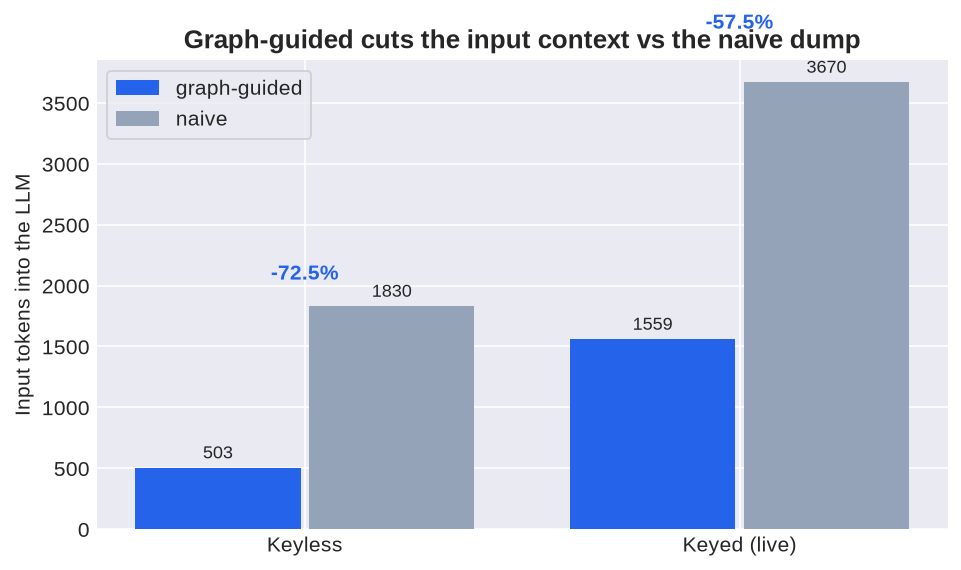

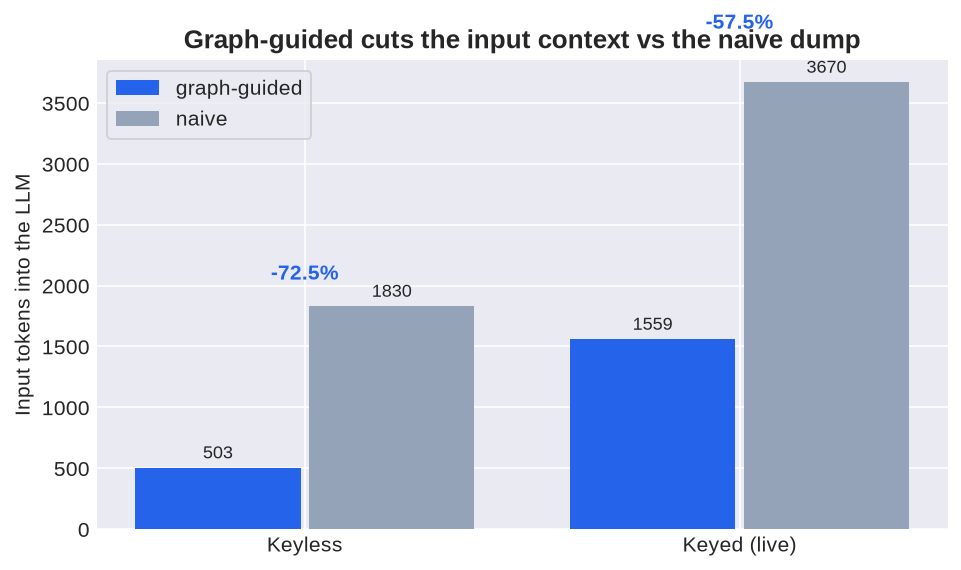

In [11]:
make_charts.fig_tokens()

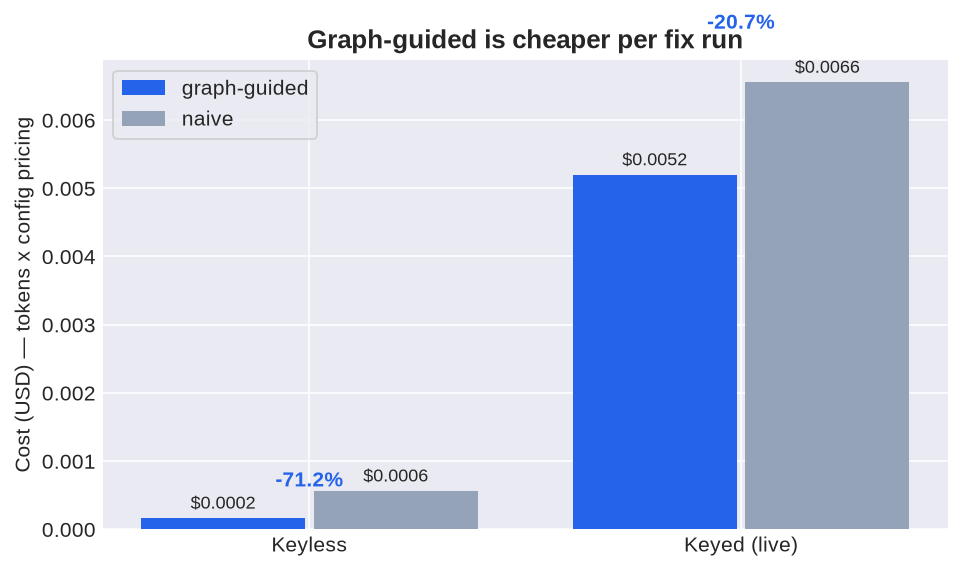

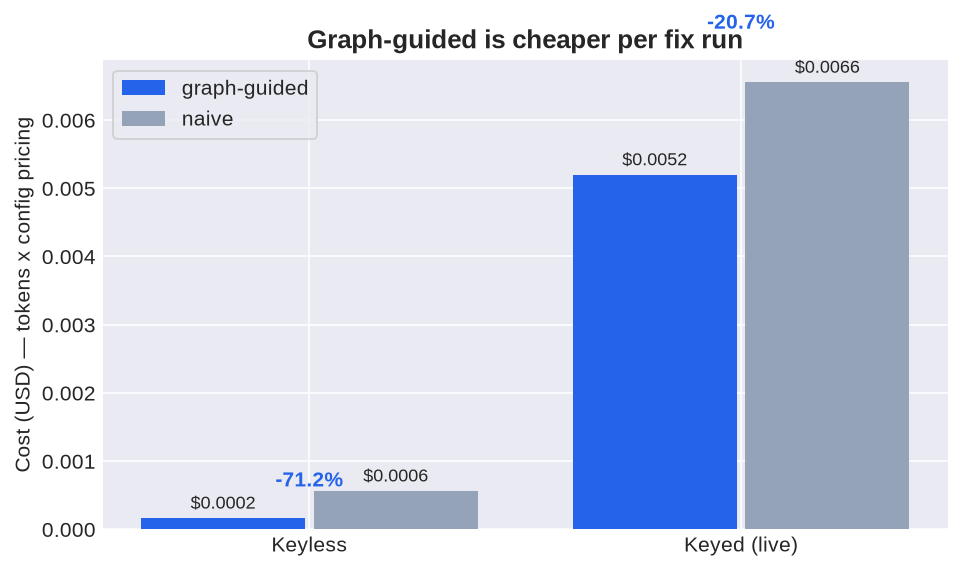

In [12]:
make_charts.fig_cost()

## Phase 7 — Reports & evidence

Human-readable evidence: root-cause narrative, before/after diff, graph diff, OOP
improvement, pipeline + traceability. **Output:** the one-root-cause finding the whole
project converges on.

In [13]:
print("reports/:")
for r in sorted(Path("reports").glob("*.md")):
    print("  ", r.name)

print("\n— Root cause (one cause, not five bugs) —")
rc = Path("reports/root_cause.md").read_text().splitlines()
i = rc.index("> **The `Polygon` class was started as the program's central abstraction and then")
print("\n".join(rc[i : i + 2]))

reports/:
   README.md
   crew_rerun_findings.md
   diagrams.md
   diff_polygons.md
   graph_diff.md
   oop_improvement.md
   pipeline.md
   research_questions.md
   root_cause.md
   run_journey.md
   screenshots.md
   token_comparison.md
   traceability.md

— Root cause (one cause, not five bugs) —
> **The `Polygon` class was started as the program's central abstraction and then
> abandoned half-finished, so every downstream computation re-implements, by hand, the state


## Phase 8 — README + self-grade

The final gate: an honest, keyless self-assessment (R8.9) — structural checks (baseline
hashes, `hot.md`↔graph consistency, required artifacts) **plus** the real quality gates
(`ruff`, `mypy --strict`, `pytest ≥90%`, file-size/anti-pattern scanners) — and the rubric
number. **Output:** the self-grade report.

In [14]:
report = sdk.self_grade()  # runs the real gates — takes ~30-60s
print(report.render())

EX04 self-grade: 90 / 100  [PASS]

  [PASS] requirement-coverage — 8 R-ids mapped to existing artifacts
  [PASS] hot.md-consistent — exists with wikilinks
  [PASS] prefix-baselines-unmodified — all baseline hashes match
  [PASS] token-trace — report totals reconcile with gatekeeper ledgers
  [PASS] self-grade-documented — 90 / 100 present in KNOWN_LIMITATIONS
  [PASS] gate:ruff — All checks passed!
  [PASS] gate:mypy — Success: no issues found in 57 source files
  [PASS] gate:coverage — 278 passed in 19.83s
  [PASS] gate:file-sizes — File-size check passed — all files within 150 lines.
  [PASS] gate:no-hardcoded — No-hardcoded check passed — no secrets/model-ids/absolute paths in src/.
  [PASS] gate:anti-patterns — Anti-pattern check passed — no shipped anti-patterns in src/.


---
### Recap

| Phase | Block above | Deliverable |
|---|---|---|
| 0 Planning | docs + requirement IDs | `docs/ASSIGNMENT.md`, ADRs |
| 1 Scaffold | package + config | `src/`, `config/*.json` |
| 2 graph_reader | graph shape + centrality | `GraphReader` |
| 3 weakness_detector | 6 signals → findings | ranked hypotheses |
| 4 Obsidian vault | generated `hot.md` | `obsidian/hot.md` |
| 5 LangGraph agent | graph-guided vs naive trace | `agent_workflow/` + fix |
| 6 Token comparison | input-token reduction | `reports/token_comparison.md` |
| 7 Reports | one root cause | `reports/*.md` |
| 8 Self-grade | gates + rubric | self-grade report |

Every block ran **keyless**; keyed live-run numbers are frozen under `reports/`.